# AOP-Wiki Use Case 1: Impaired Learning and Memory Key Event

> Overarching Goal: Define a pipeline for using Translator to find mechanistic information associated with AOP-Wiki Key Events (KEs) and Key Event Relationships (KERs) as a project for the NCATS Data Translator ROVER program

This first use case focusses on AOP-Wiki [Key Event 341: "Impaired Learning and Memory](https://aopwiki.org/events/341)

Recommended resources:
- https://arax.ncats.io/
- Biolink Documentation: https://biolink.github.io/biolink-model/
  - Visualizations - Categories: https://biolink.github.io/biolink-model/categories.html
- https://ncatstranslator.github.io/Translator_component_toolkit/components.html#key-components 


1. Use https://arax.ncats.io/ to identify synonyms for "Impaired Learning and Memory"
- No matches for "Impaired Learning and Memory"
- 1 match for "Impaired Memory", https://arax.ncats.io/?term=Impaired%20memory
- Try "memory": 5 nodes for memory by itself, https://arax.ncats.io/?term=memory
- Learning alone - https://arax.ncats.io/?term=learning 
- learning difficulties has 5 nodes: http://arax.ncats.io/?term=learning%20difficulties
  - The CURIE is UMLS:C0424939

2. Run select scripts from `notebooks/Connection_finder.ipynb` to explore TCT toolkit and outputs (below).

In [12]:
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import TCT

import time
import pprint as pp

def load_translator_resources():
    """
    Load the necessary resources for the Translator.
    """
    Translator_KP_info,APInames= translator_kpinfo.get_translator_kp_info()
    metaKG = translator_metakg.get_KP_metadata(APInames) 
    APInames,metaKG = translator_metakg.add_plover_API(APInames, metaKG)
    return  APInames, metaKG, Translator_KP_info

start_time = time.time()
print("Start time: ", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time)))
APInames, metaKG, Translator_KP_info= load_translator_resources()

API_withMetaKG = list(set(metaKG['API']))

API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

categories_for_aop_ao_nodes = [
    'biolink:PhysiologicalProcess',
    'biolink:Behavior',
    'biolink:PhysiologicalProcess',
    'biolink:Pathway',
    'biolink:SmallMolecule',
    'biolink:ProteinFamily',
    'biolink:PairwiseGeneToGeneInteraction',
    'biolink:GenomicEntity',
    'biolink:BiologicalEntity',
    'biolink:EnvironmentalExposure',
    'biolink:ClinicalFinding',
    'biolink:ChemicalMixture',
    'biolink:Gene',
    'biolink:BiologicalProcess',
    'biolink:PhenotypicFeature',
    'biolink:BehavioralFeature',
    'biolink:Virus',
    'biolink:ChemicalEntity',
    'biolink:PathologicalProcess',
    'biolink:Disease',
    'biolink:EnvironmentalProcess']

def find_neighborhood(search_term, node2_categories, api_names, meta_kg, api_predicates):
    """
    Find the neighborhood for a given search_term using TCT's Neiborhood_finder function.
    """
    return TCT.Neiborhood_finder(search_term,
                                node2_categories = node2_categories,
                                APInames = api_names,
                                metaKG = meta_kg,
                                API_predicates = api_predicates)   


def visualize_results(result_ranked, result_parsed, input_node_id):
    """
    Visualize the results using TCT's visulization_one_hop_ranking function.
    """
    TCT.visulization_one_hop_ranking(result_ranked, 
                                    result_parsed,
                                    num_of_nodes = 50,
                                    input_query = input_node_id,
                                    fontsize = 5)


def visualize_results_for_neighbors(search_term):
    """
    Visualize the results for neighbors of a given search_term.
    """
    # Find neighborhood
    input_node_id, \
    result, \
    result_parsed, \
    result_ranked_by_primary_infores = find_neighborhood(search_term, categories_for_aop_ao_nodes, APInames, metaKG, API_predicates)

    print(f"Input node ID for '{search_term}': {input_node_id}")
    print(f"Number of parsed results: {len(result_parsed)}")
    print(f"Number of ranked results by primary infores: {len(result_ranked_by_primary_infores)}")
    pp.pprint(result)

    # Visualize results
    print(f"Visualizing results for neighbors of '{search_term}' (input node ID: {input_node_id})")
    TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores, 
                                    result_parsed,
                                    num_of_nodes = 50,
                                    input_query = input_node_id,
                                    fontsize = 5)
    
# Example usage:
# visualize_results_for_neighbors("Memory")  # Memory impairment 

end_time = time.time()
execution_time = end_time - start_time
print(f"Cell execution time for part 1: {execution_time:.4f} seconds")

Start time:  2025-09-05 20:26:17
Cell execution time for part 1: 32.2204 seconds


## KERs associated with KE 341

2 events upstream of 341, which seem redundant are:
- KE 386 Decrease of neuronal network function
- 618 Decreased, Neuronal network function in adult brain

Check https://arax.ncats.io/ for "neuronal network", no results, but ["neural network"](http://arax.ncats.io/?term=Neural%20network) has 2 nodes

Q for Translator team - what is represented by the ARAX synonym query search? I am surprised the "neuronal network" didn't pull up "neural network"

UMLS:C1184191
'MolePro' generated an exception: argument of type 'NoneType' is not iterable
'Microbiome KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'Multiomics KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
RTX KG2 - TRAPI 1.5.0: Success!
'Automat-robokop(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-drug-central(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-hetionet(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-pharos(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-ubergraph(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-monarchinitiative(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-cam-kp(Trapi v1.5.0)' generated an exception: argument

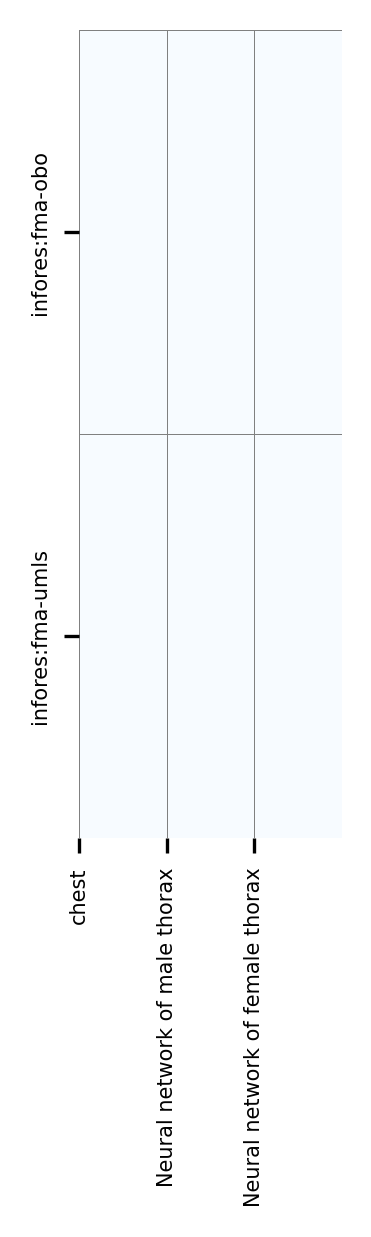

[Text(0.5, 0, 'chest'), Text(1.5, 0, 'Neural network of male thorax'), Text(2.5, 0, 'Neural network of female thorax')]


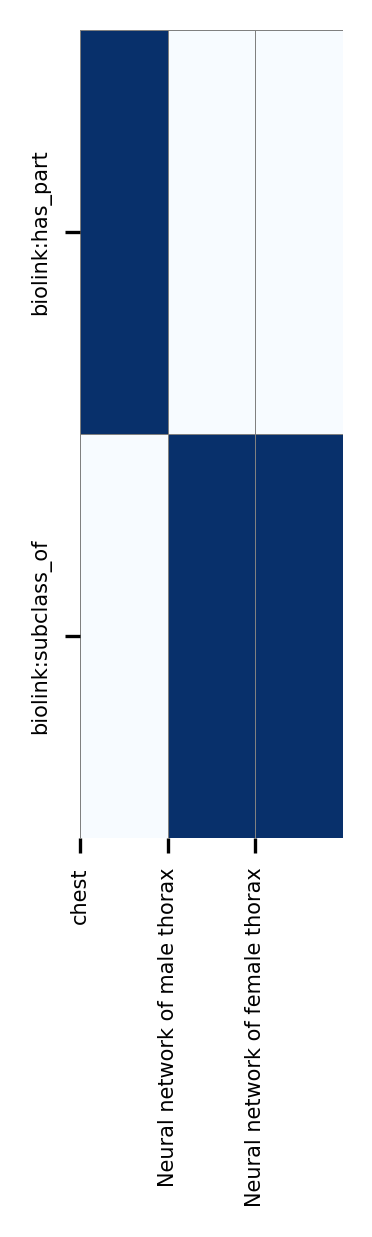

Cell execution time: 49.7733 seconds


In [13]:
start_time = time.time()
# visualize_results_for_neighbors("Neural networks")
# Yields an error - ValueError: zero-size array to reduction operation fmin which has no identity
visualize_results_for_neighbors("Neural network")

end_time = time.time()
execution_time = end_time - start_time
print(f"Cell execution time: {execution_time:.4f} seconds")

In [ ]:
start_time = time.time()
visualize_results_for_neighbors("Neural networks")
# Yields an error - ValueError: zero-size array to reduction operation fmin which has no identity

end_time = time.time()
execution_time = end_time - start_time
print(f"Cell execution time: {execution_time:.4f} seconds")